# Paper Figure-style trajectory sanity check — pinned paper parameters

This notebook is a stricter paper-parameter sanity check. It explicitly pins the graph/environment generation parameters from the paper, checks quasi-strong connectivity, logs the number of training transition pairs before each campaign, and uses a paper-style row-softmax linear graph learner.

The goal is not to exactly reproduce the original figure graph, because the paper does not publish the exact graph seed/adjacency, but to remove hidden default differences and make the run auditable.

In [1]:
from __future__ import annotations

import math
import random
import time
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

# Find repo root from the notebook location or current working directory.
def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for p in [start, *start.parents]:
        if (p / "opinion_dynamics").exists():
            return p
    raise RuntimeError(
        "Could not find repo root containing opinion_dynamics/. "
        "Run this notebook from the repo or set REPO_ROOT manually."
    )

REPO_ROOT = find_repo_root()
print("REPO_ROOT:", REPO_ROOT)

import sys
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from rl_envs_forge.envs.network_graph.graph_utils import (
    compute_laplacian,
    compute_eigenvector_centrality,
)
from opinion_dynamics.utils.env_setup import EnvironmentFactory
from opinion_dynamics.baseline import centrality_based_continuous_control

C:\Users\Chainsword\AppData\Local\Temp\ipykernel_42152\710415197.py:10: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


REPO_ROOT: d:\Work\repos\RL\unknown_graph_networks


## Configuration

The defaults are a single representative paper-style run. Change `TOPOLOGY_SEED` and `INITIAL_PERMUTATION_SEED` to inspect other graphs/initial permutations.

`BETA_PER_CAMPAIGN = 1.0` with `u_bar = 0.2` means the water-filling allocation can fully control up to five agents per campaign.

For closer visual comparison to the paper figure, the plotting default is `PLOT_TIME_ORIGIN = "first_control"`. This shifts the passive observation interval out of the main trajectory panels so the first actual campaign is at `t = 0`.


In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using DEVICE:", DEVICE)

STUDY_DATE = "2026_07_12"
STUDY_NAME = "paper_trajectory_sanity_pinned_paper_params"
RESULTS_DIR = REPO_ROOT / "opinion_dynamics" / "experiments" / "results" / f"experiment_{STUDY_DATE}_{STUDY_NAME}"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print("Results dir:", RESULTS_DIR)

# -----------------------------------------------------------------------------
# Paper settings from the empirical trajectory section.
# -----------------------------------------------------------------------------
DYNAMICS = "laplacian"
TOPOLOGY_SEED = 3
INITIAL_PERMUTATION_SEED = 0

N_AGENTS = 15
BA_ATTACHMENT_PARAMETER = 2
BA_PRUNE_MAX_FRAC = 0.5
BA_QSC_TOL = 1e-8
BA_MAX_TRIES = 500

PAPER_H = 2.0
PAPER_S = 0.5
OMEGA = 1.0
U_BAR = 0.2

# The paper says the first campaign is at nonzero time, usually h, so the learner
# sees one passive interval before the first planning/control stage.
PASSIVE_OBSERVATION_INTERVALS = 1

# Paper text: M + 1 = 5 campaigns.
NUM_CONTROLLED_CAMPAIGNS = 5

# The paper states per-agent budget u_bar=0.2, but the excerpt does not explicitly
# state beta_k. This keeps the same per-campaign budget used in our previous sanity
# notebook: enough budget to fill five nodes at u_bar=0.2.
BETA_PER_CAMPAIGN = 1.0

# Paper-style fitting.
LR = 1e-3
L2_LAMBDA = 0.0
FIT_MAX_STEPS = 50_000
FIT_MAE_STOP = 1e-3
FIT_BATCH_SIZE = 256
FIT_CHECK_EVERY = 500
SUPPRESS_FIT_LOGS = False

# Learner option.
# The paper parameterizes A by row-softmax and suppresses diagonal/self-connections
# through a regularizer rather than hard-masking by construction.
LEARNER_DIAG_MODE = "softmax_diag_penalty"
DIAG_PENALTY_LAMBDA = 1e-2

# Observation-pair handling.
# h/s = 4 integration ticks. The paper text says the learner gets only 3 samples
# before the first planning stage and 12 by the last campaign. If the env returns
# both interval endpoints, using all consecutive pairs gives 4 pairs/interval.
# This mode caps each interval to 3 consecutive pairs to match the paper wording.
OBSERVATION_PAIR_MODE = "paper_3_pairs_per_interval"  # or "all_pairs"
PAIRS_PER_INTERVAL_FOR_PAPER_MODE = int(round(PAPER_H / PAPER_S)) - 1

# Plotting / diagnostics.
# "first_control" shifts time so the first controlled campaign is at t=0.
# "absolute" shows the passive interval from t=0 to t=h.
PLOT_TIME_ORIGIN = "first_control"
SHOW_PASSIVE_INTERVAL_IN_PLOTS = False
SEED_SWEEP_MAX = 50

INITIAL_STATE_SEED_BASE = 902_000
TRAIN_SEED_BASE = 731_000

# Explicit factory overrides. The notebook applies these before creating the env
# so we are not silently relying on repo defaults.
PAPER_ENV_FACTORY_OVERRIDES = {
    "num_agents": N_AGENTS,
    "graph_model": "barabasi_albert",
    "ba_m": BA_ATTACHMENT_PARAMETER,
    "ba_prune_max_frac": BA_PRUNE_MAX_FRAC,
    "ba_qsc_tol": BA_QSC_TOL,
    "ba_max_tries": BA_MAX_TRIES,
    "max_u": U_BAR,
    "desired_opinion": OMEGA,
    "t_campaign": PAPER_H,
    "t_s": PAPER_S,
    "terminate_when_converged": False,
}

paper_param_audit = pd.DataFrame([
    {"parameter": "N", "paper": 15, "notebook": N_AGENTS},
    {"parameter": "BA attachment AP", "paper": 2, "notebook": BA_ATTACHMENT_PARAMETER},
    {"parameter": "directed by pruning up to half edges", "paper": "up to 0.5", "notebook": BA_PRUNE_MAX_FRAC},
    {"parameter": "quasi-strongly connected", "paper": "exactly one zero Laplacian eigenvalue", "notebook": f"checked with tol={BA_QSC_TOL}"},
    {"parameter": "x0", "paper": "random permutation of evenly spaced [0,1]", "notebook": "same"},
    {"parameter": "M + 1 campaigns", "paper": 5, "notebook": NUM_CONTROLLED_CAMPAIGNS},
    {"parameter": "h", "paper": 2.0, "notebook": PAPER_H},
    {"parameter": "omega", "paper": 1.0, "notebook": OMEGA},
    {"parameter": "u_bar", "paper": 0.2, "notebook": U_BAR},
    {"parameter": "s", "paper": 0.5, "notebook": PAPER_S},
    {"parameter": "learning rate", "paper": 0.001, "notebook": LR},
    {"parameter": "fit max steps", "paper": 50_000, "notebook": FIT_MAX_STEPS},
    {"parameter": "MAE stop", "paper": 0.001, "notebook": FIT_MAE_STOP},
    {"parameter": "training pairs per interval", "paper": "3 samples stated in text", "notebook": OBSERVATION_PAIR_MODE},
    {"parameter": "beta_k", "paper": "not explicit in excerpt", "notebook": BETA_PER_CAMPAIGN},
])

display(paper_param_audit)

config = {
    "dynamics": DYNAMICS,
    "topology_seed": TOPOLOGY_SEED,
    "initial_permutation_seed": INITIAL_PERMUTATION_SEED,
    "paper_env_factory_overrides": PAPER_ENV_FACTORY_OVERRIDES,
    "passive_observation_intervals": PASSIVE_OBSERVATION_INTERVALS,
    "num_controlled_campaigns": NUM_CONTROLLED_CAMPAIGNS,
    "beta_per_campaign": BETA_PER_CAMPAIGN,
    "fit_max_steps": FIT_MAX_STEPS,
    "fit_mae_stop": FIT_MAE_STOP,
    "learner_diag_mode": LEARNER_DIAG_MODE,
    "diag_penalty_lambda": DIAG_PENALTY_LAMBDA,
    "observation_pair_mode": OBSERVATION_PAIR_MODE,
    "pairs_per_interval_for_paper_mode": PAIRS_PER_INTERVAL_FOR_PAPER_MODE,
    "plot_time_origin": PLOT_TIME_ORIGIN,
    "seed_sweep_max": SEED_SWEEP_MAX,
}
config

Using DEVICE: cpu
Results dir: d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_07_12_paper_trajectory_sanity_pinned_paper_params


,parameter,paper,notebook
0,N,15,15
1,BA attachment AP,2,2
2,directed by pruning up to half edges,up to 0.5,0.5
3,quasi-strongly connected,exactly one zero Laplacian eigenvalue,checked with tol=1e-08
4,x0,"random permutation of evenly spaced [0,1]",same
5,M + 1 campaigns,5,5
6,h,2.0,2.0
7,omega,1.0,1.0
8,u_bar,0.2,0.2
9,s,0.5,0.5


{'dynamics': 'laplacian',
 'topology_seed': 3,
 'initial_permutation_seed': 0,
 'paper_env_factory_overrides': {'num_agents': 15,
  'graph_model': 'barabasi_albert',
  'ba_m': 2,
  'ba_prune_max_frac': 0.5,
  'ba_qsc_tol': 1e-08,
  'ba_max_tries': 500,
  'max_u': 0.2,
  'desired_opinion': 1.0,
  't_campaign': 2.0,
  't_s': 0.5,
  'terminate_when_converged': False},
 'passive_observation_intervals': 1,
 'num_controlled_campaigns': 5,
 'beta_per_campaign': 1.0,
 'fit_max_steps': 50000,
 'fit_mae_stop': 0.001,
 'learner_diag_mode': 'softmax_diag_penalty',
 'diag_penalty_lambda': 0.01,
 'observation_pair_mode': 'paper_3_pairs_per_interval',
 'pairs_per_interval_for_paper_mode': 3,
 'plot_time_origin': 'first_control',
 'seed_sweep_max': 50}

## Helpers

The identifier here deliberately uses the paper's Euler one-step model:

```text
x_next_i = x_i + s * sum_j A_ij * (x_j - x_i)
```

By default, the learned matrix is parameterized as a row-wise softmax and the diagonal is discouraged with a diagonal penalty. This is closer to the paper description than hard-masking the diagonal. Set `LEARNER_DIAG_MODE = "hard_zero"` to recover the older behavior.


In [3]:
def set_global_seed(seed: int) -> None:
    seed = int(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def as_vector_max_u(max_u: Any, n: int) -> np.ndarray:
    u = np.asarray(max_u, dtype=float)
    if u.ndim == 0:
        return np.full(n, float(u), dtype=float)
    u = u.reshape(-1).astype(float)
    if u.shape != (n,):
        raise ValueError(f"max_u must be scalar or shape ({n},), got {u.shape}")
    return u


def sanitize_centrality(v: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    v = np.asarray(v, dtype=float).reshape(-1)
    v = np.nan_to_num(v, nan=0.0, posinf=0.0, neginf=0.0)
    if v.sum() < 0:
        v = -v
    v = np.maximum(v, 0.0)
    s = float(v.sum())
    if s <= eps:
        v = np.abs(v)
        s = float(v.sum())
    if s <= eps:
        return np.full_like(v, 1.0 / len(v))
    return v / s


def centrality_from_A(A: np.ndarray) -> np.ndarray:
    L = compute_laplacian(np.asarray(A, dtype=float))
    return sanitize_centrality(compute_eigenvector_centrality(L))


def make_paper_initial_opinions(n: int, permutation_seed: int) -> np.ndarray:
    rng = np.random.default_rng(INITIAL_STATE_SEED_BASE + int(permutation_seed))
    x = np.linspace(0.0, 1.0, int(n), dtype=float)
    return rng.permutation(x)


def set_initial_state(env: Any, x0: np.ndarray) -> None:
    x0 = np.asarray(x0, dtype=float).reshape(-1)
    if hasattr(env, "initial_opinions"):
        try:
            env.initial_opinions = x0.copy()
        except Exception:
            pass
    env.opinions = x0.copy()
    if hasattr(env, "state"):
        try:
            env.state = x0.copy()
        except Exception:
            pass


def clone_env_from_template(
    env_template: Any,
    *,
    dynamics_model: Optional[str] = None,
    h: float = PAPER_H,
    s: float = PAPER_S,
    omega: float = OMEGA,
    u_bar: float = U_BAR,
    terminate_when_converged: bool = False,
) -> Any:
    n = int(env_template.num_agents)
    kwargs = dict(
        connectivity_matrix=np.array(env_template.connectivity_matrix, copy=True),
        num_agents=n,
        max_u=np.full(n, float(u_bar), dtype=float),
        desired_opinion=float(omega),
        t_campaign=float(h),
        t_s=float(s),
        dynamics_model=str(dynamics_model if dynamics_model is not None else getattr(env_template, "dynamics_model", "laplacian")),
        control_resistance=np.array(getattr(env_template, "control_resistance", np.zeros(n)), copy=True),
        max_steps=int(getattr(env_template, "max_steps", 10_000)),
        opinion_end_tolerance=float(getattr(env_template, "opinion_end_tolerance", 0.01)),
        control_beta=float(getattr(env_template, "control_beta", 0.4)),
        normalize_reward=bool(getattr(env_template, "normalize_reward", False)),
        terminal_reward=float(getattr(env_template, "terminal_reward", 0.0)),
        terminate_when_converged=bool(terminate_when_converged),
        seed=int(getattr(env_template, "seed", 0)) if getattr(env_template, "seed", None) is not None else None,
    )
    EnvCls = env_template.__class__
    return EnvCls(**kwargs)


def apply_paper_factory_overrides(factory: Any) -> None:
    """Pin paper graph/env parameters without depending silently on defaults."""
    if hasattr(factory, "base_config") and isinstance(factory.base_config, dict):
        factory.base_config.update(PAPER_ENV_FACTORY_OVERRIDES)
    else:
        print("Warning: EnvironmentFactory has no dict base_config; using get_randomized_env defaults.")


def make_base_env(topology_seed: int, dynamics_model: str = DYNAMICS) -> Any:
    factory = EnvironmentFactory()
    apply_paper_factory_overrides(factory)
    env = factory.get_randomized_env(seed=int(topology_seed), dynamics_model=str(dynamics_model))
    env = clone_env_from_template(
        env,
        dynamics_model=dynamics_model,
        h=PAPER_H,
        s=PAPER_S,
        omega=OMEGA,
        u_bar=U_BAR,
        terminate_when_converged=False,
    )
    return env


def raw_pairs_from_intermediate(intermediate_states: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    inter = np.asarray(intermediate_states, dtype=float)
    if inter.ndim != 2 or inter.shape[0] < 2:
        raise ValueError(f"Expected intermediate_states with at least 2 rows, got shape={inter.shape}")
    return inter[:-1], inter[1:]


def pairs_from_intermediate(intermediate_states: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """Extract training transition pairs.

    all_pairs: use every consecutive pair returned by the environment.
    paper_3_pairs_per_interval: cap each h=2, s=0.5 interval to 3 pairs, matching
    the paper's statement that only three samples are available before the first
    planning stage. If the environment already returns only three pairs, this is a no-op.
    """
    X, Y = raw_pairs_from_intermediate(intermediate_states)
    if OBSERVATION_PAIR_MODE == "all_pairs":
        return X, Y
    if OBSERVATION_PAIR_MODE == "paper_3_pairs_per_interval":
        max_pairs = int(PAIRS_PER_INTERVAL_FOR_PAPER_MODE)
        if max_pairs <= 0:
            raise ValueError("PAIRS_PER_INTERVAL_FOR_PAPER_MODE must be positive")
        return X[:max_pairs], Y[:max_pairs]
    raise ValueError(f"Unknown OBSERVATION_PAIR_MODE={OBSERVATION_PAIR_MODE!r}")


def uniform_budget_action(max_u: np.ndarray, budget: float) -> np.ndarray:
    max_u = np.asarray(max_u, dtype=float).reshape(-1)
    n = max_u.size
    u = np.zeros(n, dtype=float)
    remaining = min(float(budget), float(max_u.sum()))
    active = np.ones(n, dtype=bool)
    while remaining > 1e-12 and active.any():
        idxs = np.where(active)[0]
        share = remaining / len(idxs)
        progressed = False
        for i in idxs:
            add = min(share, float(max_u[i] - u[i]))
            if add > 0:
                u[i] += add
                remaining -= add
                progressed = True
            if u[i] >= max_u[i] - 1e-12:
                active[i] = False
        if not progressed:
            break
    return u

In [4]:
class PaperLinearGraphIdentifier(nn.Module):
    """Paper-style row-stochastic adjacency learner using Euler one-step dynamics.

    diag_mode options:
      - "softmax_diag_penalty": A = softmax(Theta), diagonal suppressed through loss penalty.
      - "hard_zero": A = softmax(Theta), diagonal masked to zero, rows renormalized.

    The first option is closer to the paper text. The second is useful as a stricter
    zero-diagonal ablation.
    """

    def __init__(
        self,
        N: int,
        s: float,
        l2_lambda: float = 0.0,
        diag_mode: str = LEARNER_DIAG_MODE,
        diag_penalty_lambda: float = DIAG_PENALTY_LAMBDA,
    ):
        super().__init__()
        self.N = int(N)
        self.s = float(s)
        self.l2_lambda = float(l2_lambda)
        self.diag_mode = str(diag_mode)
        self.diag_penalty_lambda = float(diag_penalty_lambda)
        if self.diag_mode not in {"softmax_diag_penalty", "hard_zero"}:
            raise ValueError(f"Unknown diag_mode={diag_mode!r}")
        self.Theta = nn.Parameter(torch.zeros(self.N, self.N))
        nn.init.kaiming_uniform_(self.Theta, a=0.0)
        self.register_buffer("_diag_mask", 1.0 - torch.eye(self.N))
        self.last_fit_info = {}

    def A_hat(self) -> torch.Tensor:
        A = F.softmax(self.Theta, dim=1)
        if self.diag_mode == "hard_zero":
            A = A * self._diag_mask
            rs = A.sum(dim=1, keepdim=True)
            rs = torch.where(rs > 0, rs, torch.ones_like(rs))
            A = A / rs
        return A

    def predict_next(self, x: torch.Tensor) -> torch.Tensor:
        A = self.A_hat()
        neighbor_avg = x @ A.T
        return x + self.s * (neighbor_avg - x)

    def loss(self, x: torch.Tensor, x_next: torch.Tensor):
        pred = self.predict_next(x)
        mse = F.mse_loss(pred, x_next)
        l2 = (self.Theta ** 2).sum()
        A = self.A_hat()
        # Mean diagonal mass is scale-stable across N and discourages self-connections
        # without hard-clamping them. This is closer to the paper's diagonal suppression.
        diag_penalty = torch.diagonal(A).mean()
        if self.diag_mode == "hard_zero":
            diag_penalty = torch.zeros((), dtype=mse.dtype, device=mse.device)
        loss = mse + self.l2_lambda * l2 + self.diag_penalty_lambda * diag_penalty
        return loss, {
            "mse": mse.detach(),
            "l2": l2.detach(),
            "diag_penalty": diag_penalty.detach(),
        }


def train_paper_linear_identifier(
    model: PaperLinearGraphIdentifier,
    data_x: np.ndarray,
    data_x_next: np.ndarray,
    *,
    lr: float = LR,
    batch_size: int = FIT_BATCH_SIZE,
    max_steps: int = FIT_MAX_STEPS,
    mae_stop: float = FIT_MAE_STOP,
    fit_check_every: int = FIT_CHECK_EVERY,
    device: str = DEVICE,
    suppress_logs: bool = SUPPRESS_FIT_LOGS,
) -> Tuple[np.ndarray, Dict[str, Any]]:
    model.to(device)
    X = torch.tensor(np.asarray(data_x, dtype=np.float32), dtype=torch.float32, device=device)
    Y = torch.tensor(np.asarray(data_x_next, dtype=np.float32), dtype=torch.float32, device=device)
    n = int(X.shape[0])
    if n == 0:
        raise ValueError("No training pairs provided.")

    opt = torch.optim.Adam(model.parameters(), lr=float(lr))
    stop_reason = "max_steps"
    t0 = time.perf_counter()

    last_diag_mass = np.nan
    for step in range(int(max_steps)):
        idx = torch.randint(0, n, (min(int(batch_size), n),), device=device)
        loss, loss_parts = model.loss(X[idx], Y[idx])
        opt.zero_grad()
        loss.backward()
        opt.step()

        if step % int(fit_check_every) == 0 or step == int(max_steps) - 1:
            with torch.no_grad():
                yhat = model.predict_next(X)
                mae = float((yhat - Y).abs().mean().item())
                last_diag_mass = float(torch.diagonal(model.A_hat()).mean().item())
            if (not suppress_logs) and (step % 2000 == 0 or mae <= mae_stop):
                print(
                    f"[paper-linear-fit] step={step} mae={mae:.5g} "
                    f"diag_mass={last_diag_mass:.4g} n_pairs={n}"
                )
            if mae <= float(mae_stop):
                stop_reason = "mae_stop"
                break

    fit_time = time.perf_counter() - t0
    with torch.no_grad():
        A = model.A_hat().detach().cpu().numpy()
        yhat = model.predict_next(X)
        final_mae = float((yhat - Y).abs().mean().item())
        identity_mae = float((X - Y).abs().mean().item())
        diag_mass = float(np.diag(A).mean())

    info = {
        "steps_run": int(step + 1),
        "stop_reason": stop_reason,
        "train_mae": final_mae,
        "identity_mae": identity_mae,
        "model_over_identity": final_mae / (identity_mae + 1e-12),
        "n_pairs": n,
        "fit_time_sec": float(fit_time),
        "diag_mass_mean": diag_mass,
        "diag_mode": model.diag_mode,
        "diag_penalty_lambda": model.diag_penalty_lambda,
    }
    model.last_fit_info = info
    return A, info

## Rollout routines

The learned policy follows the paper-style loop:

1. observe one passive interval with zero control;
2. fit the graph model;
3. allocate with water filling from learned centrality;
4. observe the next interval and append data;
5. refit and repeat until all 5 controlled campaigns are used.

In [5]:
def step_env_collect(env: Any, action: np.ndarray) -> Tuple[np.ndarray, float, bool, bool, np.ndarray]:
    x_next, reward, done, truncated, info = env.step(np.asarray(action, dtype=float))
    inter = info.get("intermediate_states", None)
    if inter is None:
        raise RuntimeError("env.step did not return info['intermediate_states']")
    return np.asarray(x_next, dtype=float), float(reward), bool(done), bool(truncated), np.asarray(inter, dtype=float)


def rollout_fixed_policy(
    env_template: Any,
    x0: np.ndarray,
    *,
    policy_name: str,
    v_policy: Optional[np.ndarray] = None,
    beta_per_campaign: float = BETA_PER_CAMPAIGN,
    passive_intervals: int = PASSIVE_OBSERVATION_INTERVALS,
    num_controlled_campaigns: int = NUM_CONTROLLED_CAMPAIGNS,
) -> Dict[str, Any]:
    env = clone_env_from_template(env_template, terminate_when_converged=False)
    env.reset()
    set_initial_state(env, x0)

    states = [np.asarray(x0, dtype=float).copy()]
    actions = []
    rewards = []
    boundary_times = [0.0]
    intermediate_states_list = []

    # Passive observation window before first control decision.
    for _ in range(int(passive_intervals)):
        u = np.zeros(env.num_agents, dtype=float)
        x_next, r, done, trunc, inter = step_env_collect(env, u)
        actions.append(u.copy())
        rewards.append(r)
        states.append(x_next.copy())
        intermediate_states_list.append(inter.copy())
        boundary_times.append(boundary_times[-1] + float(env.t_campaign))

    for _ in range(int(num_controlled_campaigns)):
        if policy_name == "no_control":
            u = np.zeros(env.num_agents, dtype=float)
        elif policy_name == "uniform":
            u = uniform_budget_action(as_vector_max_u(env.max_u, env.num_agents), beta_per_campaign)
        elif policy_name == "true_A_centrality":
            if v_policy is None:
                raise ValueError("v_policy is required for true_A_centrality")
            u, _ = centrality_based_continuous_control(env, beta_per_campaign, v=v_policy)
        else:
            raise ValueError(f"Unknown policy_name={policy_name}")

        x_next, r, done, trunc, inter = step_env_collect(env, u)
        actions.append(u.copy())
        rewards.append(r)
        states.append(x_next.copy())
        intermediate_states_list.append(inter.copy())
        boundary_times.append(boundary_times[-1] + float(env.t_campaign))

    return {
        "policy": policy_name,
        "states": np.asarray(states, dtype=float),
        "actions": np.asarray(actions, dtype=float),
        "rewards": np.asarray(rewards, dtype=float),
        "boundary_times": np.asarray(boundary_times, dtype=float),
        "intermediate_states_list": intermediate_states_list,
    }


def rollout_learned_paper_linear(
    env_template: Any,
    x0: np.ndarray,
    *,
    topology_seed: int,
    initial_seed: int,
    beta_per_campaign: float = BETA_PER_CAMPAIGN,
    passive_intervals: int = PASSIVE_OBSERVATION_INTERVALS,
    num_controlled_campaigns: int = NUM_CONTROLLED_CAMPAIGNS,
) -> Dict[str, Any]:
    env = clone_env_from_template(env_template, terminate_when_converged=False)
    env.reset()
    set_initial_state(env, x0)

    N = int(env.num_agents)
    train_seed = TRAIN_SEED_BASE + 10_000 * int(topology_seed) + 100 * int(initial_seed)
    set_global_seed(train_seed)

    states = [np.asarray(x0, dtype=float).copy()]
    actions = []
    rewards = []
    boundary_times = [0.0]
    intermediate_states_list = []
    A_hats = []
    v_hats = []
    fit_infos = []
    buf_x, buf_y = [], []

    # Passive observation window before first learned control decision.
    for _ in range(int(passive_intervals)):
        u = np.zeros(N, dtype=float)
        x_next, r, done, trunc, inter = step_env_collect(env, u)
        actions.append(u.copy())
        rewards.append(r)
        states.append(x_next.copy())
        intermediate_states_list.append(inter.copy())
        boundary_times.append(boundary_times[-1] + float(env.t_campaign))
        Xp, Yp = pairs_from_intermediate(inter)
        buf_x.append(Xp)
        buf_y.append(Yp)

    model = PaperLinearGraphIdentifier(
        N=N,
        s=float(env.t_s),
        l2_lambda=L2_LAMBDA,
        diag_mode=LEARNER_DIAG_MODE,
        diag_penalty_lambda=DIAG_PENALTY_LAMBDA,
    )

    for k in range(int(num_controlled_campaigns)):
        X = np.concatenate(buf_x, axis=0)
        Y = np.concatenate(buf_y, axis=0)
        A_hat, fit_info = train_paper_linear_identifier(
            model,
            X,
            Y,
            lr=LR,
            batch_size=FIT_BATCH_SIZE,
            max_steps=FIT_MAX_STEPS,
            mae_stop=FIT_MAE_STOP,
            fit_check_every=FIT_CHECK_EVERY,
            device=DEVICE,
            suppress_logs=SUPPRESS_FIT_LOGS,
        )
        v_hat = centrality_from_A(A_hat)
        A_hats.append(np.asarray(A_hat, dtype=float).copy())
        v_hats.append(v_hat.copy())
        fit_infos.append(dict(fit_info, controlled_campaign_index=int(k)))

        u, _ = centrality_based_continuous_control(env, beta_per_campaign, v=v_hat)
        x_next, r, done, trunc, inter = step_env_collect(env, u)
        actions.append(u.copy())
        rewards.append(r)
        states.append(x_next.copy())
        intermediate_states_list.append(inter.copy())
        boundary_times.append(boundary_times[-1] + float(env.t_campaign))
        Xp, Yp = pairs_from_intermediate(inter)
        buf_x.append(Xp)
        buf_y.append(Yp)

    return {
        "policy": "learned_linear",
        "states": np.asarray(states, dtype=float),
        "actions": np.asarray(actions, dtype=float),
        "rewards": np.asarray(rewards, dtype=float),
        "boundary_times": np.asarray(boundary_times, dtype=float),
        "intermediate_states_list": intermediate_states_list,
        "A_hats": A_hats,
        "v_hats": v_hats,
        "fit_infos": fit_infos,
    }

## Paper graph checks

These checks make the graph assumptions explicit: row-stochastic adjacency, approximately zero diagonal, and quasi-strong connectivity (one zero eigenvalue of the Laplacian).

In [6]:
def laplacian_zero_eigenvalue_count(A: np.ndarray, tol: float = BA_QSC_TOL) -> int:
    L = compute_laplacian(np.asarray(A, dtype=float))
    eigs = np.linalg.eigvals(L)
    return int(np.sum(np.abs(eigs) <= float(tol)))


def assert_paper_graph_conditions(A: np.ndarray, *, tol: float = BA_QSC_TOL) -> None:
    A = np.asarray(A, dtype=float)
    assert A.shape == (N_AGENTS, N_AGENTS), f"Expected A shape {(N_AGENTS, N_AGENTS)}, got {A.shape}"
    assert np.all(A >= -1e-12), "A has negative weights"
    assert np.allclose(A.sum(axis=1), 1.0, atol=1e-8), "A is not row-stochastic"
    diag_max = float(np.max(np.abs(np.diag(A))))
    zero_count = laplacian_zero_eigenvalue_count(A, tol=tol)
    print("Graph condition checks")
    print("  shape:", A.shape)
    print("  row-sum min/max:", float(A.sum(axis=1).min()), float(A.sum(axis=1).max()))
    print("  max |diag(A)|:", diag_max)
    print("  zero Laplacian eigenvalue count:", zero_count)
    if diag_max > 1e-10:
        print("  note: diagonal is not exactly zero; check repo graph generator if this is unexpected")
    assert zero_count == 1, "Graph is not quasi-strongly connected by the paper criterion"


## Run one paper-style trajectory experiment

In [7]:
base_env = make_base_env(TOPOLOGY_SEED, DYNAMICS)
A_true = np.asarray(base_env.connectivity_matrix, dtype=float)
v_true = centrality_from_A(A_true)
x0 = make_paper_initial_opinions(base_env.num_agents, INITIAL_PERMUTATION_SEED)

print("N:", base_env.num_agents)
assert_paper_graph_conditions(A_true)
print("A row sums min/max:", A_true.sum(axis=1).min(), A_true.sum(axis=1).max())
print("x0:", np.round(x0, 3))
print("true centrality:", np.round(v_true, 3))

run_t0 = time.perf_counter()
learned = rollout_learned_paper_linear(
    base_env,
    x0,
    topology_seed=TOPOLOGY_SEED,
    initial_seed=INITIAL_PERMUTATION_SEED,
)
true_A = rollout_fixed_policy(base_env, x0, policy_name="true_A_centrality", v_policy=v_true)
uniform = rollout_fixed_policy(base_env, x0, policy_name="uniform")
no_control = rollout_fixed_policy(base_env, x0, policy_name="no_control")
print(f"Done in {time.perf_counter() - run_t0:.1f}s")

N: 15
Graph condition checks
  shape: (15, 15)
  row-sum min/max: 0.9999999999999998 1.0
  max |diag(A)|: 0.0
  zero Laplacian eigenvalue count: 1
A row sums min/max: 0.9999999999999998 1.0
x0: [1.    0.857 0.5   0.071 0.357 0.571 0.143 0.214 0.714 0.286 0.929 0.643
 0.    0.786 0.429]
true centrality: [0.145 0.052 0.117 0.092 0.107 0.018 0.128 0.043 0.037 0.05  0.04  0.045
 0.043 0.044 0.038]
[paper-linear-fit] step=0 mae=0.049984 diag_mass=0.05881 n_pairs=3
[paper-linear-fit] step=2000 mae=0.0045917 diag_mass=0.01534 n_pairs=3
[paper-linear-fit] step=4000 mae=0.0015445 diag_mass=0.004358 n_pairs=3
[paper-linear-fit] step=5000 mae=0.00084117 diag_mass=0.00258 n_pairs=3
[paper-linear-fit] step=0 mae=0.0049386 diag_mass=0.002576 n_pairs=6
[paper-linear-fit] step=2000 mae=0.001477 diag_mass=0.0005013 n_pairs=6
[paper-linear-fit] step=3500 mae=0.00093107 diag_mass=0.0002217 n_pairs=6
[paper-linear-fit] step=0 mae=0.0031389 diag_mass=0.0002215 n_pairs=9
[paper-linear-fit] step=2000 mae=0.0

## Graph convergence-speed diagnostic

The paper figure uses one sampled BA graph, but the exact graph/seed is not provided. Different valid BA/pruned graphs can have very different Laplacian spectral gaps, which changes how fast no-control consensus visually converges. This cell reports the current graph's spectral gap and shows a quick seed sweep so you can pick a faster/slower graph for visual matching.


In [8]:
def laplacian_spectral_gap(A: np.ndarray, tol: float = 1e-8) -> float:
    L = compute_laplacian(np.asarray(A, dtype=float))
    eigs = np.linalg.eigvals(L)
    real_parts = np.sort(np.real(eigs))
    positive = real_parts[real_parts > tol]
    return float(positive[0]) if len(positive) else np.nan

current_gap = laplacian_spectral_gap(A_true)
print("Current topology seed:", TOPOLOGY_SEED)
print("Laplian spectral gap:", current_gap)
print("Approx consensus time constant 1/gap:", 1.0 / current_gap if current_gap > 0 else np.inf)

rows = []
for seed in range(int(SEED_SWEEP_MAX)):
    env_tmp = make_base_env(seed, DYNAMICS)
    A_tmp = np.asarray(env_tmp.connectivity_matrix, dtype=float)
    gap = laplacian_spectral_gap(A_tmp)
    rows.append({
        "topology_seed": seed,
        "spectral_gap": gap,
        "approx_time_constant": 1.0 / gap if gap > 0 else np.inf,
    })

gap_df = pd.DataFrame(rows).sort_values("spectral_gap", ascending=False).reset_index(drop=True)
print("Fastest-converging seeds in this sweep:")
display(gap_df.head(10).round(5))
print("Slowest-converging seeds in this sweep:")
display(gap_df.tail(10).round(5))

Current topology seed: 3
Laplian spectral gap: 0.3364092031493093
Approx consensus time constant 1/gap: 2.972570282377702
Fastest-converging seeds in this sweep:


,topology_seed,spectral_gap,approx_time_constant
0,30,0.47219,2.11778
1,0,0.45222,2.21133
2,37,0.43953,2.27513
3,9,0.43391,2.30463
4,28,0.42346,2.36149
5,15,0.42048,2.37821
6,4,0.40286,2.48227
7,11,0.39860,2.50876
8,18,0.39797,2.51276
9,22,0.38753,2.58044


Slowest-converging seeds in this sweep:


,topology_seed,spectral_gap,approx_time_constant
40,46,0.24461,4.08815
41,29,0.24281,4.11851
42,31,0.23459,4.26280
43,5,0.23323,4.28761
44,38,0.22192,4.50605
45,17,0.21795,4.58824
46,26,0.20074,4.98148
47,40,0.13392,7.46688
48,19,0.07421,13.47544
49,21,0.03259,30.68501


## Summary metrics

`delta` is the final consensus-value error using the true graph centrality vector: `|omega - v_true @ x_final|`.

For the linear Laplacian case, this is the paper-style objective.

In [9]:
def final_consensus_value(rollout: Dict[str, Any], v_true: np.ndarray) -> float:
    return float(np.asarray(v_true, dtype=float).reshape(-1) @ np.asarray(rollout["states"], dtype=float)[-1])


def final_delta(rollout: Dict[str, Any], v_true: np.ndarray, omega: float = OMEGA) -> float:
    return abs(float(omega) - final_consensus_value(rollout, v_true))


def final_mean(rollout: Dict[str, Any]) -> float:
    return float(np.asarray(rollout["states"], dtype=float)[-1].mean())

rows = []
for name, ro in [
    ("true_A_centrality", true_A),
    ("learned_linear", learned),
    ("uniform", uniform),
    ("no_control", no_control),
]:
    rows.append({
        "policy": name,
        "final_mean_opinion": final_mean(ro),
        "final_consensus_value_v_true": final_consensus_value(ro, v_true),
        "delta_to_omega": final_delta(ro, v_true),
        "total_budget_used": float(np.asarray(ro["actions"]).sum()),
    })

summary_df = pd.DataFrame(rows)
summary_df["suboptimality_vs_true_A_delta"] = summary_df["delta_to_omega"] - float(summary_df.loc[summary_df.policy == "true_A_centrality", "delta_to_omega"].iloc[0])
summary_df.round(5)

,policy,final_mean_opinion,final_consensus_value_v_true,delta_to_omega,total_budget_used,suboptimality_vs_true_A_delta
0,true_A_centrality,0.72290,0.72502,0.27498,5.0,0.00000
1,learned_linear,0.67158,0.67354,0.32646,5.0,0.05148
2,uniform,0.63796,0.63786,0.36214,5.0,0.08716
3,no_control,0.48883,0.48868,0.51132,0.0,0.23634


In [10]:
fit_df = pd.DataFrame(learned["fit_infos"])
if learned["v_hats"]:
    fit_df["v_L1_to_true"] = [float(np.abs(vh - v_true).sum()) for vh in learned["v_hats"]]
    fit_df["campaign_time"] = PAPER_H * (PASSIVE_OBSERVATION_INTERVALS + np.arange(len(fit_df)))
fit_df.round(5)

,steps_run,stop_reason,train_mae,identity_mae,model_over_identity,n_pairs,fit_time_sec,diag_mass_mean,diag_mode,diag_penalty_lambda,controlled_campaign_index,v_L1_to_true,campaign_time
0,5001,mae_stop,0.00084,0.06392,0.01316,3,6.89647,0.00258,softmax_diag_penalty,0.01,0,0.50561,2.0
1,3501,mae_stop,0.00093,0.04042,0.02303,6,4.83500,0.00022,softmax_diag_penalty,0.01,1,0.39516,4.0
2,4001,mae_stop,0.00097,0.03059,0.03178,9,5.36299,0.00002,softmax_diag_penalty,0.01,2,0.35764,6.0
3,9501,mae_stop,0.00100,0.02563,0.03899,12,12.91483,0.00000,softmax_diag_penalty,0.01,3,0.38029,8.0
4,50000,max_steps,0.00110,0.02274,0.04839,15,67.66503,0.00000,softmax_diag_penalty,0.01,4,0.39502,10.0


## Observation/sample-count sanity check

The paper text says that with `s = 0.5`, graph learning receives only three samples before the first planning stage and 12 samples by the last campaign. This cell shows exactly how many raw environment pairs and training pairs the notebook used.

In [11]:
def interval_pair_count_table(rollout: Dict[str, Any]) -> pd.DataFrame:
    rows = []
    cumulative_train_pairs = 0
    cumulative_raw_pairs = 0
    for interval_idx, inter in enumerate(rollout["intermediate_states_list"]):
        raw_x, raw_y = raw_pairs_from_intermediate(inter)
        train_x, train_y = pairs_from_intermediate(inter)
        cumulative_raw_pairs += len(raw_x)
        cumulative_train_pairs += len(train_x)
        rows.append({
            "interval_index": interval_idx,
            "interval_type": "passive" if interval_idx < PASSIVE_OBSERVATION_INTERVALS else "controlled",
            "raw_states_returned": len(inter),
            "raw_pairs_this_interval": len(raw_x),
            "train_pairs_this_interval": len(train_x),
            "cumulative_raw_pairs_after_interval": cumulative_raw_pairs,
            "cumulative_train_pairs_after_interval": cumulative_train_pairs,
        })
    return pd.DataFrame(rows)

sample_count_df = interval_pair_count_table(learned)
display(sample_count_df)
print("Fit n_pairs before each controlled campaign:", [fi["n_pairs"] for fi in learned["fit_infos"]])
print("Observation pair mode:", OBSERVATION_PAIR_MODE)


,interval_index,interval_type,raw_states_returned,raw_pairs_this_interval,train_pairs_this_interval,cumulative_raw_pairs_after_interval,cumulative_train_pairs_after_interval
0,0,passive,5,4,3,4,3
1,1,controlled,5,4,3,8,6
2,2,controlled,5,4,3,12,9
3,3,controlled,5,4,3,16,12
4,4,controlled,5,4,3,20,15
5,5,controlled,5,4,3,24,18


Fit n_pairs before each controlled campaign: [3, 6, 9, 12, 15]
Observation pair mode: paper_3_pairs_per_interval


## Paper Figure-style trajectories

The vertical jumps at campaign times are the immediate opinion shifts caused by the marketing action.

By default, this closer-to-paper notebook shifts the time axis so the first control campaign appears at `t = 0`. Set `PLOT_TIME_ORIGIN = "absolute"` to show the passive observation interval from `0` to `h`.


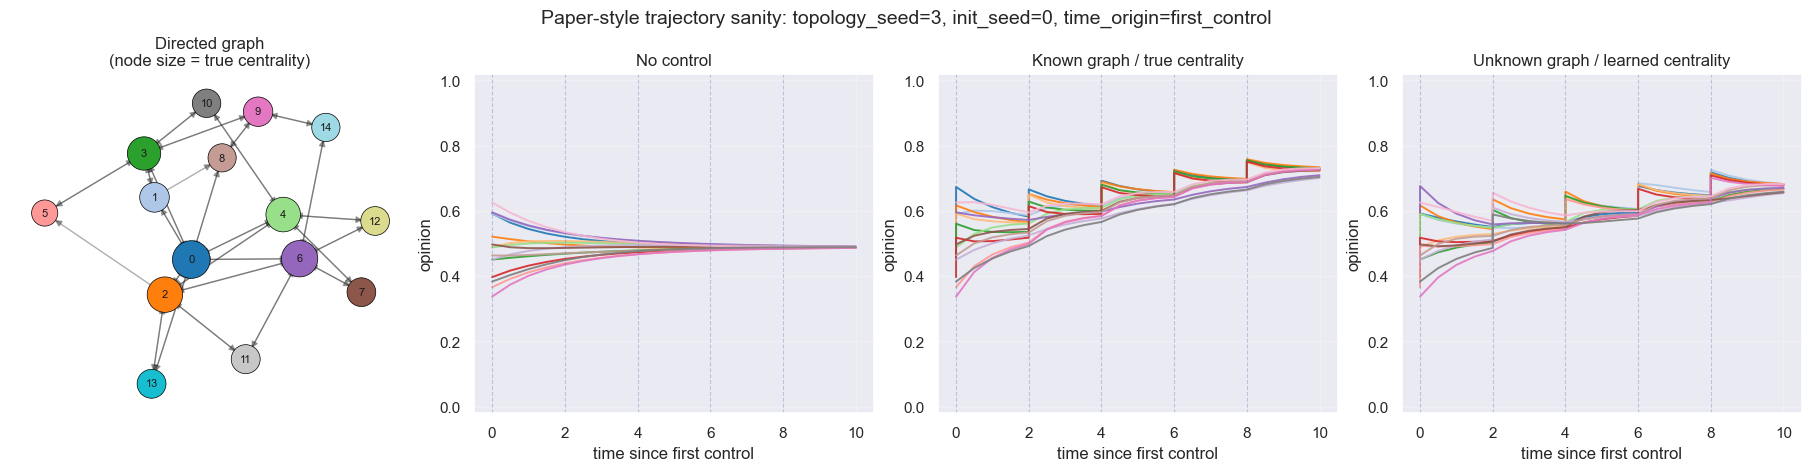

In [12]:
def rollout_time_series_with_jumps(rollout: Dict[str, Any], *, h: float = PAPER_H, omega: float = OMEGA) -> Tuple[np.ndarray, np.ndarray]:
    """Return times and node states, including same-time jump points at campaign instants."""
    states = np.asarray(rollout["states"], dtype=float)
    actions = np.asarray(rollout["actions"], dtype=float)
    segments = rollout["intermediate_states_list"]
    times: List[float] = []
    xs: List[np.ndarray] = []

    for interval_idx, (u, inter) in enumerate(zip(actions, segments)):
        t0 = float(interval_idx) * float(h)
        pre = states[interval_idx].copy()
        post = u * float(omega) + (1.0 - u) * pre

        times.append(t0)
        xs.append(pre.copy())

        if np.max(np.abs(post - pre)) > 1e-12:
            times.append(t0)
            xs.append(post.copy())

        inter = np.asarray(inter, dtype=float)
        # inter is expected to include the post-action starting state; skip it to avoid duplicates.
        if len(inter) > 1:
            local_times = np.linspace(t0, t0 + float(h), len(inter))
            for tt, xx in zip(local_times[1:], inter[1:]):
                times.append(float(tt))
                xs.append(np.asarray(xx, dtype=float).copy())

    return np.asarray(times, dtype=float), np.asarray(xs, dtype=float)


def align_time_for_plot(t: np.ndarray, X: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """Optionally shift/hide the passive interval for paper-style visual comparison."""
    t = np.asarray(t, dtype=float).copy()
    X = np.asarray(X, dtype=float)
    if PLOT_TIME_ORIGIN == "first_control":
        t = t - PASSIVE_OBSERVATION_INTERVALS * PAPER_H
        if not SHOW_PASSIVE_INTERVAL_IN_PLOTS:
            mask = t >= -1e-12
            t = t[mask]
            X = X[mask]
            # Avoid tiny negative zeros in tick labels.
            t[np.abs(t) < 1e-12] = 0.0
    elif PLOT_TIME_ORIGIN != "absolute":
        raise ValueError("PLOT_TIME_ORIGIN must be 'absolute' or 'first_control'")
    return t, X


def campaign_line_times() -> List[float]:
    raw = [k * PAPER_H for k in range(PASSIVE_OBSERVATION_INTERVALS, PASSIVE_OBSERVATION_INTERVALS + NUM_CONTROLLED_CAMPAIGNS)]
    if PLOT_TIME_ORIGIN == "first_control":
        shift = PASSIVE_OBSERVATION_INTERVALS * PAPER_H
        return [tt - shift for tt in raw]
    return raw


def plot_node_trajectories(ax, rollout: Dict[str, Any], title: str, *, show_legend: bool = False):
    t, X = rollout_time_series_with_jumps(rollout)
    t, X = align_time_for_plot(t, X)
    n = X.shape[1]
    cmap = plt.get_cmap("tab20")
    for i in range(n):
        ax.plot(t, X[:, i], linewidth=1.4, alpha=0.9, color=cmap(i % 20), label=f"{i}" if show_legend else None)

    if PLOT_TIME_ORIGIN == "absolute" or SHOW_PASSIVE_INTERVAL_IN_PLOTS:
        ax.axvspan(0, PAPER_H, alpha=0.08, color="gray", label="passive observation" if show_legend else None)

    for tt in campaign_line_times():
        ax.axvline(tt, linestyle="--", linewidth=0.8, alpha=0.35)
    ax.set_title(title)
    ax.set_xlabel("time since first control" if PLOT_TIME_ORIGIN == "first_control" else "time")
    ax.set_ylabel("opinion")
    ax.set_ylim(-0.02, 1.02)
    ax.grid(True, alpha=0.25)
    if show_legend:
        ax.legend(title="node", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)


def plot_graph_panel(ax, A: np.ndarray, v: np.ndarray):
    import networkx as nx
    A = np.asarray(A, dtype=float)
    G = nx.DiGraph()
    for i in range(A.shape[0]):
        G.add_node(i)
    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            if A[i, j] > 1e-12:
                # A_ij means j influences i; draw j -> i.
                G.add_edge(j, i, weight=float(A[i, j]))
    pos = nx.spring_layout(G, seed=TOPOLOGY_SEED)
    sizes = 300 + 3000 * sanitize_centrality(v)
    nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", alpha=0.35, width=1.0)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=sizes, node_color=np.arange(A.shape[0]), cmap="tab20", edgecolors="black", linewidths=0.5)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=8)
    ax.set_title("Directed graph\n(node size = true centrality)")
    ax.axis("off")

fig, axes = plt.subplots(1, 4, figsize=(18, 4.6), constrained_layout=True)
plot_graph_panel(axes[0], A_true, v_true)
plot_node_trajectories(axes[1], no_control, "No control")
plot_node_trajectories(axes[2], true_A, "Known graph / true centrality")
plot_node_trajectories(axes[3], learned, "Unknown graph / learned centrality")
fig.suptitle(
    f"Paper-style trajectory sanity: topology_seed={TOPOLOGY_SEED}, init_seed={INITIAL_PERMUTATION_SEED}, "
    f"time_origin={PLOT_TIME_ORIGIN}",
    fontsize=14,
)
plt.show()

## Extra baseline: uniform control

This is not part of the paper's Figure 1, but it is useful for checking that the learned and known-graph policies are not merely benefiting from total budget injection.

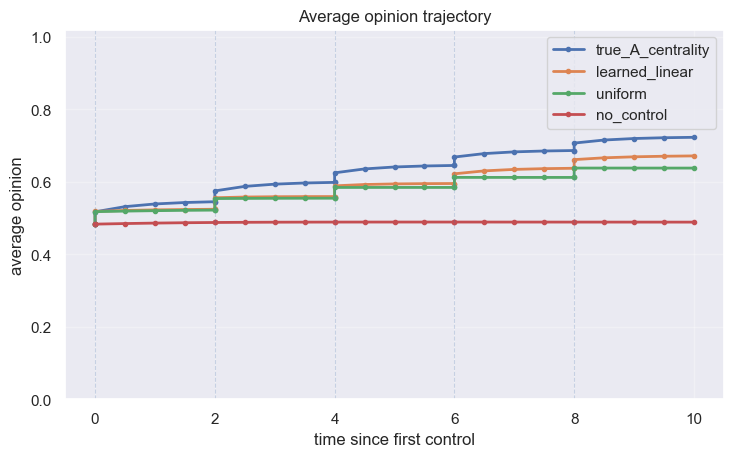

In [13]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
for name, ro in [
    ("true_A_centrality", true_A),
    ("learned_linear", learned),
    ("uniform", uniform),
    ("no_control", no_control),
]:
    t, X = rollout_time_series_with_jumps(ro)
    t, X = align_time_for_plot(t, X)
    ax.plot(t, X.mean(axis=1), marker="o", markersize=3, linewidth=2, label=name)
for tt in campaign_line_times():
    ax.axvline(tt, linestyle="--", linewidth=0.8, alpha=0.25)
if PLOT_TIME_ORIGIN == "absolute" or SHOW_PASSIVE_INTERVAL_IN_PLOTS:
    ax.axvspan(0, PAPER_H, alpha=0.08, color="gray", label="passive observation")
ax.set_title("Average opinion trajectory")
ax.set_xlabel("time since first control" if PLOT_TIME_ORIGIN == "first_control" else "time")
ax.set_ylabel("average opinion")
ax.set_ylim(0.0, 1.02)
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
plt.show()

## Learned graph diagnostics

These diagnostics are useful if the learned trajectory is not close to the known-graph trajectory.

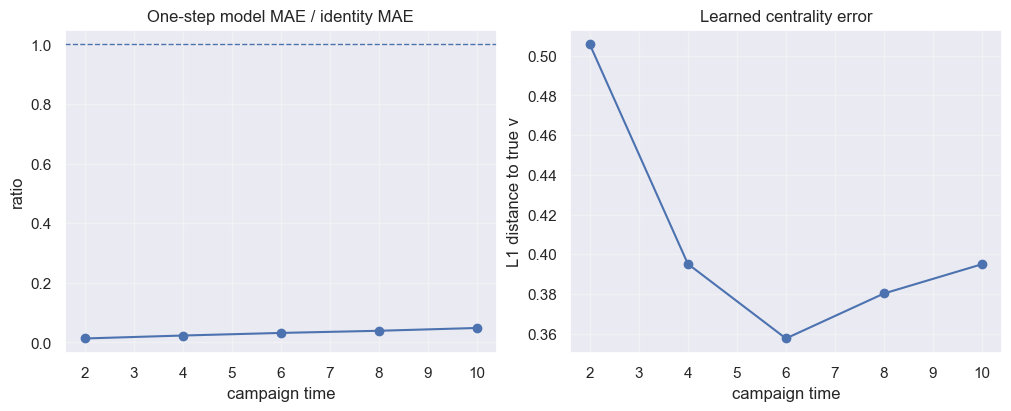

,steps_run,stop_reason,train_mae,identity_mae,model_over_identity,n_pairs,fit_time_sec,diag_mass_mean,diag_mode,diag_penalty_lambda,controlled_campaign_index,v_L1_to_true,campaign_time
0,5001,mae_stop,0.00084,0.06392,0.01316,3,6.89647,0.00258,softmax_diag_penalty,0.01,0,0.50561,2.0
1,3501,mae_stop,0.00093,0.04042,0.02303,6,4.83500,0.00022,softmax_diag_penalty,0.01,1,0.39516,4.0
2,4001,mae_stop,0.00097,0.03059,0.03178,9,5.36299,0.00002,softmax_diag_penalty,0.01,2,0.35764,6.0
3,9501,mae_stop,0.00100,0.02563,0.03899,12,12.91483,0.00000,softmax_diag_penalty,0.01,3,0.38029,8.0
4,50000,max_steps,0.00110,0.02274,0.04839,15,67.66503,0.00000,softmax_diag_penalty,0.01,4,0.39502,10.0


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
axes[0].plot(fit_df["campaign_time"], fit_df["model_over_identity"], marker="o")
axes[0].axhline(1.0, linestyle="--", linewidth=1)
axes[0].set_title("One-step model MAE / identity MAE")
axes[0].set_xlabel("campaign time")
axes[0].set_ylabel("ratio")
axes[0].grid(True, alpha=0.3)

axes[1].plot(fit_df["campaign_time"], fit_df["v_L1_to_true"], marker="o")
axes[1].set_title("Learned centrality error")
axes[1].set_xlabel("campaign time")
axes[1].set_ylabel("L1 distance to true v")
axes[1].grid(True, alpha=0.3)
plt.show()

fit_df.round(5)

## Optional: inspect actions

This shows which nodes receive budget at each controlled campaign. Campaign index 0 is the passive interval, so the first nonzero action is campaign index 1.

In [15]:
def actions_table(rollout: Dict[str, Any], name: str) -> pd.DataFrame:
    A = np.asarray(rollout["actions"], dtype=float)
    rows = []
    for k, u in enumerate(A):
        row = {"policy": name, "campaign_index": k, "time": k * PAPER_H, "budget_used": float(u.sum())}
        top = np.where(u > 1e-9)[0].tolist()
        row["controlled_nodes"] = top
        row["controlled_values"] = np.round(u[top], 3).tolist()
        rows.append(row)
    return pd.DataFrame(rows)

actions_df = pd.concat([
    actions_table(true_A, "true_A_centrality"),
    actions_table(learned, "learned_linear"),
    actions_table(uniform, "uniform"),
], ignore_index=True)
actions_df

,policy,campaign_index,time,budget_used,controlled_nodes,controlled_values
0,true_A_centrality,0,0.0,0.0,[],[]
1,true_A_centrality,1,2.0,1.0,"[0, 2, 3, 4, 6]","[0.2, 0.2, 0.2, 0.2, 0.2]"
2,true_A_centrality,2,4.0,1.0,"[0, 2, 3, 4, 6]","[0.2, 0.2, 0.2, 0.2, 0.2]"
3,true_A_centrality,3,6.0,1.0,"[0, 2, 3, 4, 6]","[0.2, 0.2, 0.2, 0.2, 0.2]"
4,true_A_centrality,4,8.0,1.0,"[0, 2, 3, 4, 6]","[0.2, 0.2, 0.2, 0.2, 0.2]"
5,true_A_centrality,5,10.0,1.0,"[0, 2, 3, 4, 6]","[0.2, 0.2, 0.2, 0.2, 0.2]"
6,learned_linear,0,0.0,0.0,[],[]
7,learned_linear,1,2.0,1.0,"[2, 5, 6, 7, 8]","[0.2, 0.2, 0.2, 0.2, 0.2]"
8,learned_linear,2,4.0,1.0,"[2, 4, 9, 13, 14]","[0.2, 0.2, 0.2, 0.2, 0.2]"
9,learned_linear,3,6.0,1.0,"[1, 2, 3, 4, 7]","[0.2, 0.2, 0.2, 0.2, 0.2]"


## Interpretation checklist

For a healthy paper-style sanity run, look for:

- learned-linear trajectories close to true-graph trajectories;
- both learned and true-graph trajectories clearly above no-control;
- learned-linear usually above uniform, although this can vary by seed;
- `model_over_identity < 1`, preferably much smaller;
- centrality error decreasing or staying in a range that still gives a similar ranking of influential nodes.